# Build a Baseline Multi-label Classifier (TF-IDF + One-vs-Rest)

In [1]:
!pip install scikit-learn

**Import**

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report ,accuracy_score, hamming_loss
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from imblearn.over_sampling import RandomOverSampler

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from scipy.sparse import hstack

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

with open("../DepressionEmo/dataset/train.json" ,'r', encoding='utf-8') as f:
    data = [json.loads(line)  for line in f ]
df = pd.DataFrame(data)
df.head()

,id,title,post,text,upvotes,date,emotions,label_id
0,hhcq6e,Found out something awful,My mum had a boyfriend when I was around 6 or ...,Found out something awful ### My mum had a boy...,53,2020-06-28 11:16:59,"[anger, hopelessness, sadness]",10010100
1,d0bobn,I just want to feel wanted ya know?,"Like, I have a ton of friends, I talk to them ...","I just want to feel wanted ya know? ### Like, ...",51,2019-09-06 04:10:27,"[loneliness, sadness, emptiness, hopelessness,...",10111100
2,wy400i,Done,I’m writing this as I sit on the side of the r...,Done ### I’m writing this as I sit on the side...,8,2022-08-26 08:53:35,"[loneliness, hopelessness, sadness, worthlessn...",10111101
3,crkjga,"When nobody else celebrates you, learn to cele...",Feeling unloved can have a huge impact on the ...,"When nobody else celebrates you, learn to cele...",28,2019-08-17 10:28:21,"[loneliness, sadness]",1100
4,zq1lwl,goodbye.,I'm done. I have a bottle of jack danials and ...,goodbye. ### I'm done. I have a bottle of jack...,102,2022-12-19 19:50:52,"[emptiness, hopelessness]",110000


In [101]:
df.columns

Index(['id', 'title', 'post', 'text', 'upvotes', 'date', 'emotions',
       'label_id'],
      dtype='object')

Select relevant features. Let's predict Emotions using selected fatures.

In [48]:
x = df['text']
# x = df[['title','post']]
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['emotions'])  # this turns list of emotions into binary matrix


In [51]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),       
    max_features=10000,       
    stop_words='english'     
)
X_vectorized = vectorizer.fit_transform(x)



In [52]:
# feature_names = vectorizer.get_feature_names_out()
# df = pd.DataFrame(X_vectorized.toarray(), columns=feature_names)
# print(df.head())

# # 4. Train/Test split

In [56]:

# Example: X = text data, Y = multi-label binary encoded emotions

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# =======================
# EXPERIMENTED MODELS BELOW
# =======================

In [60]:
# pipeline = Pipeline([
#     ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
#     ('clf', OneVsRestClassifier(RandomForestClassifier(random_state=42)))
# ])

# param_grid = {
#     'clf__estimator__n_estimators': [100, 200],
#     'clf__estimator__max_depth': [None, 10, 20],
#     'clf__estimator__min_samples_split': [2, 5],
#     'clf__estimator__min_samples_leaf': [1, 2]
# }

# grid_search = GridSearchCV(pipeline, param_grid, scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)
# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_)
# print("Best F1 Score:", grid_search.best_score_)

# Logistic Regression 

In [64]:
# pipeline = Pipeline([
#     ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
#     ('clf', OneVsRestClassifier(LogisticRegression(solver='liblinear')))
# ])

# pipeline.fit(X_train, y_train)


In [67]:
# #Make predictions

# y_pred = pipeline.predict(X_test)


In [70]:

# # Predict probabilities instead of direct class labels
# y_pred_proba = pipeline.predict_proba(X_test)

# # Set a custom threshold to improve precision
# threshold = 0.7
# import numpy as np
# y_pred = (y_pred_proba >= threshold).astype(int)


In [73]:
# # Classification report
# print("Classification Report:\n")
# print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

# # Hamming loss
# print("Hamming Loss:", hamming_loss(y_test, y_pred))

# # Accuracy (not that useful for multi-label but included)
# print("Accuracy:", accuracy_score(y_test, y_pred))

In [75]:
# precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
# recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
# f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# print(f"\nMacro Precision: {precision:.4f}")
# print(f"Macro Recall:    {recall:.4f}")
# print(f"Macro F1 Score:  {f1:.4f}")

# LinearSVC

In [79]:
# pipeline = Pipeline([
#     ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
#     ('clf', OneVsRestClassifier(LinearSVC(class_weight='balanced')))
# ])

# pipeline.fit(X_train, y_train)

In [82]:
# #Make predictions

# y_pred = pipeline.predict(X_test)

In [85]:
# # Classification report
# print("Classification Report:\n")
# print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

# # Hamming loss
# print("Hamming Loss:", hamming_loss(y_test, y_pred))

# # Accuracy (not that useful for multi-label but included)
# print("Accuracy:", accuracy_score(y_test, y_pred))

In [87]:
# precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
# recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
# f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# print(f"\nMacro Precision: {precision:.4f}")
# print(f"Macro Recall:    {recall:.4f}")
# print(f"Macro F1 Score:  {f1:.4f}")

# RandomForestClassifier

In [92]:
#pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('clf', OneVsRestClassifier(RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    )))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('clf',
                 OneVsRestClassifier(estimator=RandomForestClassifier(n_estimators=200,
                                                                      random_state=42)))])

In [94]:
y_pred_proba = pipeline.predict_proba(X_test)
y_pred = ( y_pred_proba >= 0.4 ).astype(int)

In [95]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=mlb.classes_, zero_division=0))

# Hamming loss
print("Hamming Loss:", hamming_loss(y_test, y_pred))

# Accuracy (not that useful for multi-label but included)
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:

                            precision    recall  f1-score   support

                     anger       0.65      0.83      0.73       339
brain dysfunction (forget)       0.77      0.23      0.36       176
                 emptiness       0.66      0.71      0.68       319
              hopelessness       0.74      1.00      0.85       616
                loneliness       0.69      0.83      0.75       386
                   sadness       0.79      1.00      0.88       669
            suicide intent       0.83      0.69      0.75       227
             worthlessness       0.60      0.90      0.72       424

                 micro avg       0.71      0.85      0.77      3156
                 macro avg       0.72      0.77      0.72      3156
              weighted avg       0.72      0.85      0.76      3156
               samples avg       0.70      0.87      0.73      3156

Hamming Loss: 0.23180473372781066
Accuracy: 0.1349112426035503


In [96]:
precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\nMacro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1 Score:  {f1:.4f}")


Macro Precision: 0.7168
Macro Recall:    0.7726
Macro F1 Score:  0.7162


**Saving Mental Health Model**

In [98]:
joblib.dump(pipeline, "mental_health_model.pkl")

['mental_health_model.pkl']

**Saving MlB**

In [102]:
joblib.dump(mlb, "mlb.pkl")

['mlb.pkl']

In [99]:
def predict_emotions(text):
    vec = [text]
    proba = pipeline.predict_proba(vec)
    prediction = (proba >= 0.4).astype(int)
    return mlb.inverse_transform(prediction)


## 🔍 Visualize Emotion Predictions

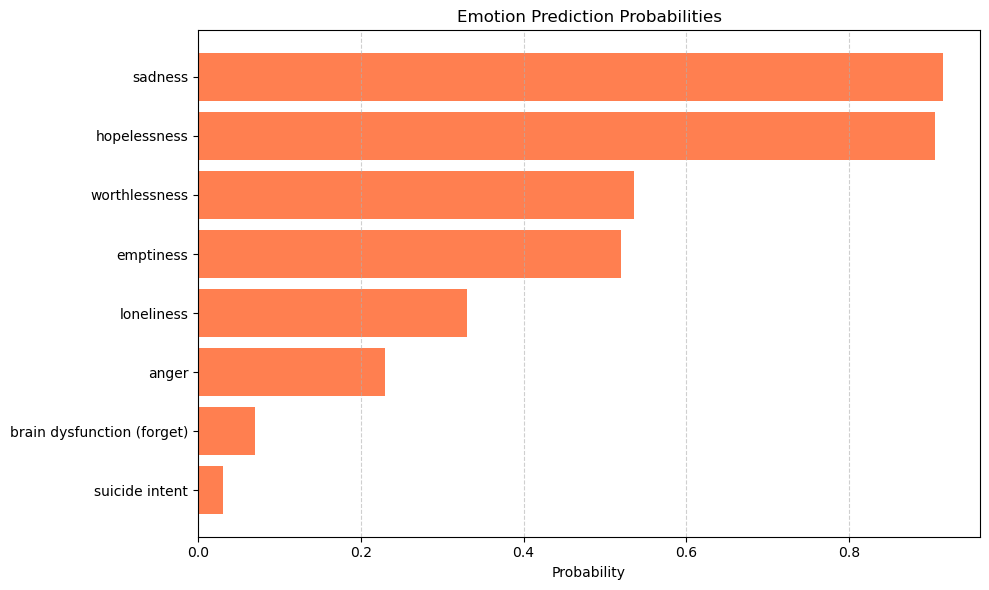

In [109]:
# Predict and visualize
text = "I feel totally lost, anxious and sad."
#text = "My thoughts are loud, chaotic, and I can’t silence them. Time feels warped — minutes stretch into hours, and nothing feels real anymore. I’m forgetting things, losing track of conversations mid-sentence. I feel like I’m losing my mind."
predict_emotions(text)  # You can still return this for reference

# Then visualize the probabilities
proba = pipeline.predict_proba([text])[0]
labels = mlb.classes_

# Bar chart
df = pd.DataFrame({'Emotion': labels, 'Probability': proba}).sort_values(by='Probability', ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(df['Emotion'], df['Probability'], color='coral')
plt.title("Emotion Prediction Probabilities")
plt.xlabel("Probability")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
